In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('HR_Analytics.csv') 

In [4]:
df

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,RM412,60,55+,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,...,4,80,0,33,5,1,29,8,11,10.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,4,80,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,4,80,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,2,80,1,12,3,3,11,7,1,9.0


## Understanding the Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

## Checking Missing Values

In [8]:
print(df.isnull().sum())



EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
Training

In [9]:
df['YearsWithCurrManager'].describe()

count    1423.000000
mean        4.118060
std         3.555484
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: YearsWithCurrManager, dtype: float64

### Handling Missing Values in YearsWithCurrManager

In [10]:
df['YearsWithCurrManager']=df['YearsWithCurrManager'].fillna(0)

In [11]:
df[df.duplicated()]

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
211,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
655,RM1470,34,26-35,No,TravelRarely,628,Research & Development,8,3,Medical,...,1,80,0,6,3,4,4,3,1,2.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
1305,RM1469,49,46-55,No,Travel_Frequently,1023,Sales,2,3,Medical,...,4,80,0,17,3,2,9,6,0,8.0
1336,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0


In [12]:
dup=df['EmpID'].duplicated().sum()
print(f"{'EmpID'}:{dup}")


EmpID:10


In [13]:
df['EmpID'][df['EmpID'].duplicated()].unique()

array(['RM1465', 'RM1468', 'RM1461', 'RM1464', 'RM1470', 'RM1466',
       'RM1463', 'RM1467', 'RM1469', 'RM1462'], dtype=object)

In [14]:
df[df.duplicated(keep=False)].sort_values('EmpID')

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
327,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
1335,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0
1336,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0
952,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
457,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
210,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
211,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0


## Removing Duplicate Records


In [15]:
df = df.drop_duplicates()

In [16]:
df.shape[0]

1473

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
print("Rows:", df.shape[0])
print("Unique IDs:", df['EmpID'].nunique())
print("Duplicate EmpIDs:", df['EmpID'].duplicated().sum())

Rows: 1473
Unique IDs: 1470
Duplicate EmpIDs: 3


In [19]:
list1=set()
for i in df['EmpID']:
    if i in list1:
        print(i)
    list1.add(i)
    
        
    

RM1465
RM1466
RM1467


In [20]:
df[df['EmpID'].isin(['RM1465', 'RM1466', 'RM1467'])].sort_values('EmpID')

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
161,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,4,80,0,5,2,3,4,2,0,0.0
162,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,4,80,0,5,2,3,4,2,0,5.0
802,RM1466,36,36-45,No,Travel_Frequently,884,Research & Development,23,2,Medical,...,3,80,1,17,3,3,5,2,0,3.0
803,RM1466,36,36-45,No,Travel_Frequently,884,Research & Development,23,2,Medical,...,3,80,1,17,3,3,5,2,0,2.0
953,RM1467,39,36-45,No,Travel_Rarely,613,Research & Development,6,1,Medical,...,1,80,1,9,5,3,7,7,1,7.0
955,RM1467,39,36-45,No,Travel_Rarely,613,Research & Development,6,1,Medical,...,1,80,1,9,5,3,7,7,1,1.0


## Removing Duplicate Employee Records

In [21]:
df = df.drop_duplicates(subset=['EmpID'], keep='first')

In [22]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate EmpIDs:", df['EmpID'].duplicated().sum())

Rows: 1470
Columns: 38
Missing values:
 EmpID                       0
Age                         0
AgeGroup                    0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
SalarySlab                  0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1470 non-null   object 
 1   Age                       1470 non-null   int64  
 2   AgeGroup                  1470 non-null   object 
 3   Attrition                 1470 non-null   object 
 4   BusinessTravel            1470 non-null   object 
 5   DailyRate                 1470 non-null   int64  
 6   Department                1470 non-null   object 
 7   DistanceFromHome          1470 non-null   int64  
 8   Education                 1470 non-null   int64  
 9   EducationField            1470 non-null   object 
 10  EmployeeCount             1470 non-null   int64  
 11  EmployeeNumber            1470 non-null   int64  
 12  EnvironmentSatisfaction   1470 non-null   int64  
 13  Gender                    1470 non-null   object 
 14  HourlyRate   

## Removing Irrelevant Features

In [24]:
df.drop(['StandardHours', 'Over18', 'EmployeeCount'],
        axis=1,
        inplace=True,
        errors='ignore')

## Renaming Columns for Better Readability

In [25]:
df=df.rename(columns={'BusinessTravel':'Business_Travel','DailyRate':'Daily_Rate','DistanceFromHome':'Distance_From_Home','EducationField':'Education_Field','EnvironmentSatisfaction':'Environment_Satisfaction','HourlyRate':'Hourly_Rate','JobInvolvement':'Job_Involvement','JobLevel':'Job_Level','JobRole':'Job_Role','JobSatisfaction':'Job_Satisfaction','MaritalStatus':'Marital_Status','MonthlyIncome':'Monthly_Income','SalarySlab':'Salary_Slab','MonthlyRate':'Monthly_Rate','NumCompaniesWorked':'Num_Companies_Worked','OverTime':'Over_Time','PercentSalaryHike':'Percent_Salary_Hike','PerformanceRating':'Performance_Rating','RelationshipSatisfaction':'Relationship_Satisfaction','StockOptionLevel':'Stock_Option_Level','TotalWorkingYears':'Total_Working_Years','TrainingTimesLastYear':'TrainingTimes_Last_Year','WorkLifeBalance':'Work_LifeBalance','YearsAtCompany':'Years_At_Company','YearsInCurrentRole':'Years_In_CurrentRole','YearsSinceLastPromotion':'YearsSinceLastPromotion','YearsWithCurrManager':'Years_With_CurrManager'})

In [26]:
df.columns

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'Business_Travel',
       'Daily_Rate', 'Department', 'Distance_From_Home', 'Education',
       'Education_Field', 'EmployeeNumber', 'Environment_Satisfaction',
       'Gender', 'Hourly_Rate', 'Job_Involvement', 'Job_Level', 'Job_Role',
       'Job_Satisfaction', 'Marital_Status', 'Monthly_Income', 'Salary_Slab',
       'Monthly_Rate', 'Num_Companies_Worked', 'Over_Time',
       'Percent_Salary_Hike', 'Performance_Rating',
       'Relationship_Satisfaction', 'Stock_Option_Level',
       'Total_Working_Years', 'TrainingTimes_Last_Year', 'Work_LifeBalance',
       'Years_At_Company', 'Years_In_CurrentRole', 'YearsSinceLastPromotion',
       'Years_With_CurrManager'],
      dtype='object')

## Correcting Inconsistent Categorical Values



In [27]:
df['Business_Travel'].replace('TraveRarely','Trave_Rarely')

0           Travel_Rarely
1           Travel_Rarely
2       Travel_Frequently
3              Non-Travel
4              Non-Travel
              ...        
1475        Travel_Rarely
1476    Travel_Frequently
1477        Travel_Rarely
1478        Travel_Rarely
1479        Travel_Rarely
Name: Business_Travel, Length: 1470, dtype: object

## CLEANING COMPLETED

In [28]:
df.loc[1470]      

EmpID                                  RM233
Age                                       59
AgeGroup                                 55+
Attrition                                 No
Business_Travel                Travel_Rarely
Daily_Rate                               818
Department                   Human Resources
Distance_From_Home                         6
Education                                  2
Education_Field                      Medical
EmployeeNumber                           321
Environment_Satisfaction                   2
Gender                                  Male
Hourly_Rate                               52
Job_Involvement                            3
Job_Level                                  1
Job_Role                     Human Resources
Job_Satisfaction                           3
Marital_Status                       Married
Monthly_Income                          2267
Salary_Slab                          Upto 5k
Monthly_Rate                           25657
Num_Compan

# EDA STARTS

In [29]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1479
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   EmpID                      1470 non-null   object 
 1   Age                        1470 non-null   int64  
 2   AgeGroup                   1470 non-null   object 
 3   Attrition                  1470 non-null   object 
 4   Business_Travel            1470 non-null   object 
 5   Daily_Rate                 1470 non-null   int64  
 6   Department                 1470 non-null   object 
 7   Distance_From_Home         1470 non-null   int64  
 8   Education                  1470 non-null   int64  
 9   Education_Field            1470 non-null   object 
 10  EmployeeNumber             1470 non-null   int64  
 11  Environment_Satisfaction   1470 non-null   int64  
 12  Gender                     1470 non-null   object 
 13  Hourly_Rate                1470 non-null   int64  
 1

,Age,Daily_Rate,Distance_From_Home,Education,EmployeeNumber,Environment_Satisfaction,Hourly_Rate,Job_Involvement,Job_Level,Job_Satisfaction,...,Performance_Rating,Relationship_Satisfaction,Stock_Option_Level,Total_Working_Years,TrainingTimes_Last_Year,Work_LifeBalance,Years_At_Company,Years_In_CurrentRole,YearsSinceLastPromotion,Years_With_CurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,3.960544
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.581371
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,1.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## TOTAL NO OF EMPLOYEES LEAVE VS NOT LEAVE

In [30]:

count_ofattrition=df['Attrition']
no_of_leave=0
no_of_no_leave=0
ID_s=[]
for j in df['Attrition']:
    if j=="Yes":
        no_of_leave+=1
        
    else:
        no_of_no_leave+=1
print("Yes:",no_of_leave,"percent:",(no_of_leave/1470)*100)
print("No:",no_of_no_leave,"percent:",(no_of_no_leave/1470)*100)
    

Yes: 237 percent: 16.122448979591837
No: 1233 percent: 83.87755102040816


In [31]:
df['Attrition'].value_counts()
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Employee Attrition (Total Employees = 1470)')

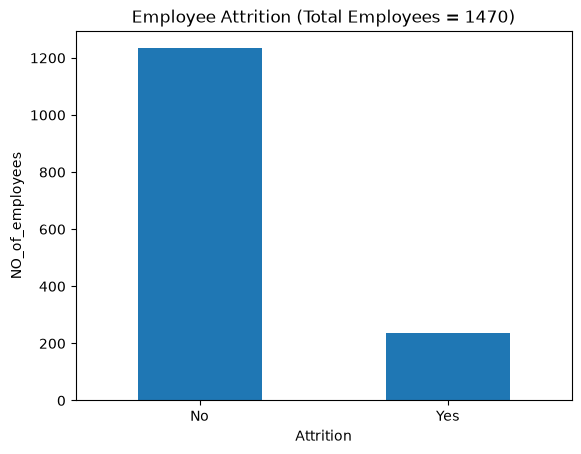

In [32]:

df['Attrition'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.ylabel("NO_of_employees")
total_emp = len(df)
plt.title(f'Employee Attrition (Total Employees = {total_emp})')


# ANALYSIS OF EMPLOYEES WHO LEAVE

In [33]:

df[df['Attrition']=='Yes']

,EmpID,Age,AgeGroup,Attrition,Business_Travel,Daily_Rate,Department,Distance_From_Home,Education,Education_Field,...,Performance_Rating,Relationship_Satisfaction,Stock_Option_Level,Total_Working_Years,TrainingTimes_Last_Year,Work_LifeBalance,Years_At_Company,Years_In_CurrentRole,YearsSinceLastPromotion,Years_With_CurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,3,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,3,4,0,0,3,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,3,4,0,0,0,3,0,0,0,0.0
6,RM1154,18,18-25,Yes,Travel_Frequently,544,Sales,3,2,Medical,...,3,3,0,0,2,4,0,0,0,0.0
8,RM128,19,18-25,Yes,Travel_Rarely,528,Sales,22,1,Marketing,...,3,4,0,0,2,2,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452,RM127,58,55+,Yes,Travel_Rarely,147,Research & Development,23,4,Medical,...,3,4,1,40,3,2,40,10,15,6.0
1455,RM596,58,55+,Yes,Travel_Rarely,286,Research & Development,2,4,Life Sciences,...,3,4,0,40,2,3,31,15,13,8.0
1456,RM661,58,55+,Yes,Travel_Frequently,781,Research & Development,2,1,Life Sciences,...,3,4,1,3,3,2,1,0,0,0.0
1458,RM701,58,55+,Yes,Travel_Rarely,289,Research & Development,2,3,Technical Degree,...,4,1,0,7,4,3,1,0,0,0.0


 ## Average distance for employees who left

In [122]:

df.groupby('Attrition')['Distance_From_Home'].mean()


Attrition
No      8.915653
Yes    10.632911
Name: Distance_From_Home, dtype: float64

## Average distance for employees who stayed

In [34]:

df[df['Attrition']=='No']['Distance_From_Home'].mean()

8.915652879156529

# Compare both at once

In [124]:

df.groupby('Attrition')['Distance_From_Home'].mean()

Attrition
No      8.915653
Yes    10.632911
Name: Distance_From_Home, dtype: float64

# Employees who left lived farther from the workplace on average (10.6 miles/km) than employees who stayed (8.9 miles/km).
# This suggests commuting distance may be associated with attrition.

Text(0, 0.5, 'Distance_travelled')

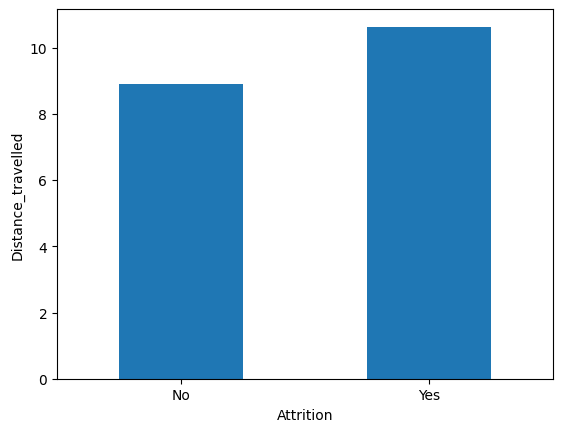

In [125]:

df.groupby('Attrition')['Distance_From_Home'].mean().plot(kind='bar')
plt.xticks(rotation=0)
plt.ylabel("Distance_travelled")

# Average Daily Rate who left

In [35]:

df[df['Attrition']=='Yes']['Daily_Rate'].mean()


750.3628691983122

# Average Daily Rate who did not left

In [ ]:

df[df['Attrition']=='No']['Daily_Rate'].mean()


# Comparing daily rate vs attrition

Text(0, 0.5, 'Daily_rate')

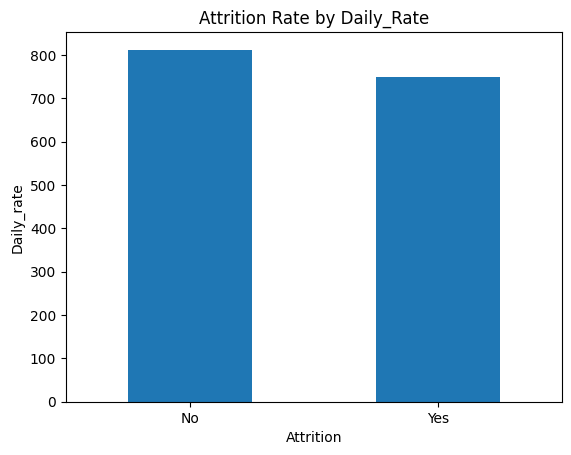

In [128]:

df.groupby('Attrition')['Daily_Rate'].mean().plot(kind='bar')
plt.title('Attrition Rate by Daily_Rate')
plt.xticks(rotation=0)
plt.ylabel('Daily_rate')

# Employees who left the organization had a lower average Daily Rate (750.36) compared to employees who stayed (812.50),
# suggesting compensation may be associated with employee retention.

Text(0, 0.5, 'Monthly_Income')

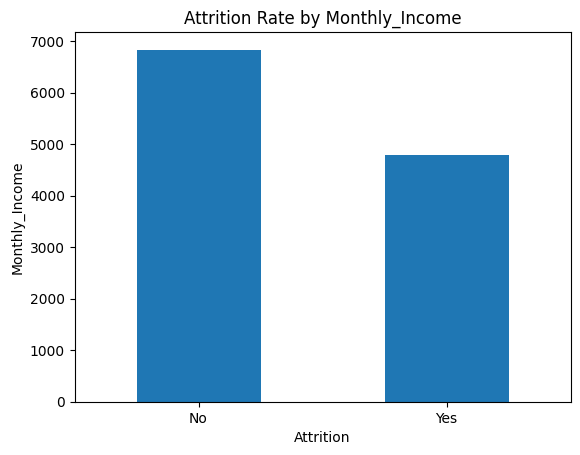

In [130]:
# Comparing Monthly_income vs attrition
df.groupby('Attrition')['Monthly_Income'].mean().plot(kind='bar')
plt.title('Attrition Rate by Monthly_Income')
plt.xticks(rotation=0)
plt.ylabel('Monthly_Income')


# Employees who left the company had a significantly lower average monthly income (4787.09) compared to employees who stayed (6832.74). 
# This suggests compensation may be a major factor influencing employee attrition.

In [132]:
# Comparing Salary_Slab vs attrition
salary_attrition = pd.crosstab(
    df['Salary_Slab'],
    df['Attrition'],
    normalize='index'
) * 100
print(salary_attrition)

Attrition           No        Yes
Salary_Slab                      
10k-15k      86.486486  13.513514
15k+         96.240602   3.759398
5k-10k       88.863636  11.136364
Upto 5k      78.237650  21.762350


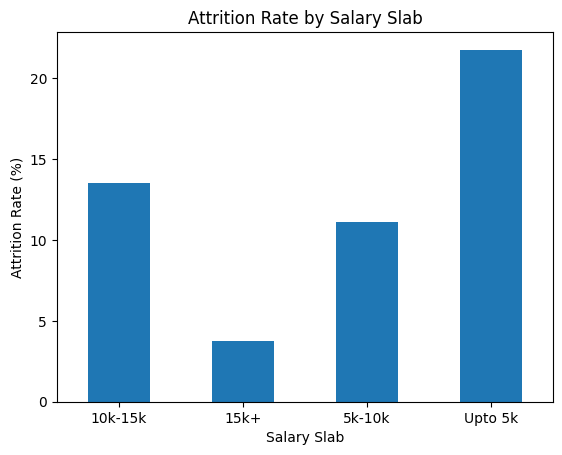

In [133]:
salary_attrition['Yes'].plot(kind='bar')
plt.title('Attrition Rate by Salary Slab')
plt.xlabel('Salary Slab')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()


# Overtime vs Attrition

In [134]:

overtime_attrition = pd.crosstab(
    df['Over_Time'],
    df['Attrition'],
    normalize='index'
) * 100

print(overtime_attrition)

Attrition         No        Yes
Over_Time                      
No         89.563567  10.436433
Yes        69.471154  30.528846


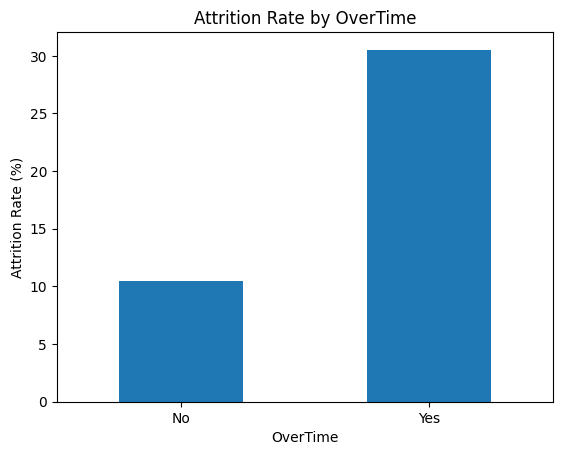

In [135]:
overtime_attrition['Yes'].plot(kind='bar')
plt.title('Attrition Rate by OverTime')
plt.xlabel('OverTime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

# EDA
# Employees who work overtime have an attrition rate of 30.53%, compared to only 10.44% for employees who do not work overtime.

In [138]:
travel_attrition = pd.crosstab(
    df['Business_Travel'],
    df['Attrition'],
    normalize='index'
) * 100

print(travel_attrition)


Attrition                  No        Yes
Business_Travel                         
Non-Travel          92.000000   8.000000
TravelRarely       100.000000   0.000000
Travel_Frequently   75.090253  24.909747
Travel_Rarely       84.942085  15.057915


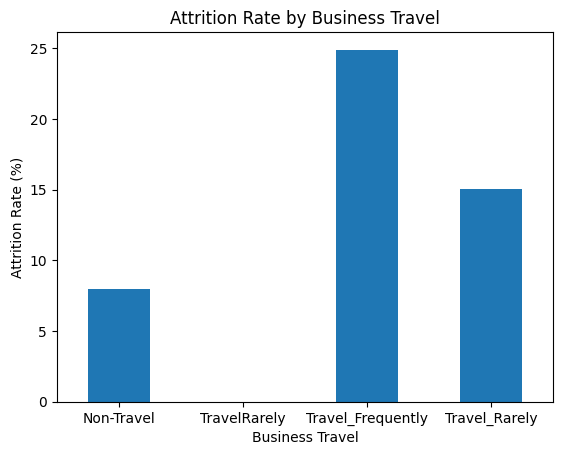

In [139]:
travel_attrition['Yes'].plot(kind='bar')
plt.title('Attrition Rate by Business Travel')
plt.xlabel('Business Travel')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64


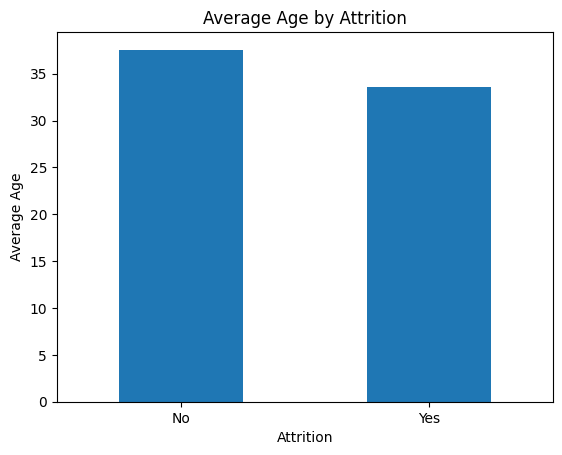

In [141]:
age_attrition = df.groupby('Attrition')['Age'].mean()

print(age_attrition)

age_attrition.plot(kind='bar')
plt.title('Average Age by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
plt.show()

# EDA Finding
# Employees who left the company had an average age of 33.6 years, whereas employees who stayed had an average age of 37.6 years.



years_attrition = df.groupby('Attrition')['Years_At_Company'].mean()

print(years_attrition)

years_attrition.plot(kind='bar')
plt.title('Average Years at Company by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Average Years')
plt.xticks(rotation=0)
plt.show()

# EDA Finding
# Employees who left the organization had an average tenure of 5.1 years, compared to 7.4 years for employees who stayed.


Attrition                  No        Yes
Stock_Option_Level                      
0                   75.594295  24.405705
1                   90.604027   9.395973
2                   92.405063   7.594937
3                   82.352941  17.647059


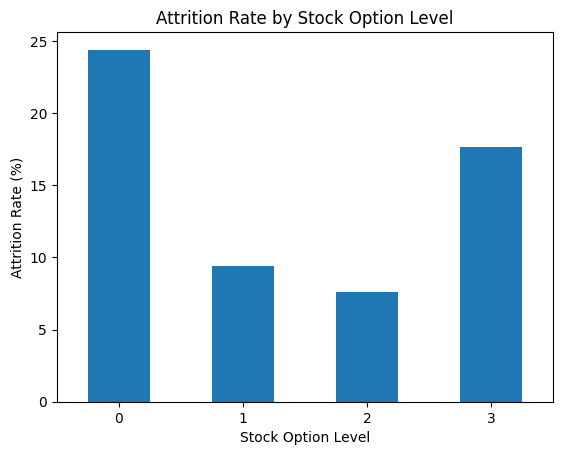

In [145]:
stock_attrition = pd.crosstab(
    df['Stock_Option_Level'],
    df['Attrition'],
    normalize='index'
) * 100

print(stock_attrition)

stock_attrition['Yes'].plot(kind='bar')
plt.title('Attrition Rate by Stock Option Level')
plt.xlabel('Stock Option Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.show()

# EDA Finding
# Employees with no stock options have an attrition rate of 24.4%, whereas employees with stock options generally have much lower attrition rates (7.6%–9.4%).



# lOGISTIC_REGRESSION

In [181]:

X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [182]:
y = y.map({'No': 0, 'Yes': 1})

In [183]:
print(X.select_dtypes(include='object').columns)

Index(['EmpID', 'AgeGroup', 'Business_Travel', 'Department', 'Education_Field',
       'Gender', 'Job_Role', 'Marital_Status', 'Salary_Slab', 'Over_Time'],
      dtype='object')


In [184]:
X = pd.get_dummies(X, drop_first=True)

In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [186]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [187]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [188]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [189]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [190]:
y_pred = model.predict(X_test)

In [191]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8231292517006803


In [192]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[241   0]
 [ 52   1]]
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       241
           1       1.00      0.02      0.04        53

    accuracy                           0.82       294
   macro avg       0.91      0.51      0.47       294
weighted avg       0.85      0.82      0.75       294



In [193]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [194]:
y_pred = model.predict(X_test)

In [195]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[241   0]
 [ 52   1]]
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       241
           1       1.00      0.02      0.04        53

    accuracy                           0.82       294
   macro avg       0.91      0.51      0.47       294
weighted avg       0.85      0.82      0.75       294



In [196]:
print(model.class_weight)
print(y_train.value_counts())
print(model)

balanced
Attrition
0    992
1    184
Name: count, dtype: int64
LogisticRegression(class_weight='balanced', max_iter=1000)


In [197]:
print(y.unique())

[1 0]


In [198]:
pd.Series(y_pred).value_counts()

0    293
1      1
Name: count, dtype: int64

# Random Forest

In [199]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

In [200]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [201]:
# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [202]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

In [203]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [204]:
y_pred_rf = rf.predict(X_test)

In [205]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8333333333333334
[[241   0]
 [ 49   4]]
              precision    recall  f1-score   support

          No       0.83      1.00      0.91       241
         Yes       1.00      0.08      0.14        53

    accuracy                           0.83       294
   macro avg       0.92      0.54      0.52       294
weighted avg       0.86      0.83      0.77       294



In [206]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

print(importance.sort_values(ascending=False).head(10))

Age                    0.044011
Monthly_Income         0.043200
Years_At_Company       0.039376
Total_Working_Years    0.037595
EmployeeNumber         0.036524
Daily_Rate             0.035329
Monthly_Rate           0.034024
Hourly_Rate            0.029553
Distance_From_Home     0.029196
Over_Time_Yes          0.028062
dtype: float64


In [207]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[241   0]
 [ 49   4]]
              precision    recall  f1-score   support

          No       0.83      1.00      0.91       241
         Yes       1.00      0.08      0.14        53

    accuracy                           0.83       294
   macro avg       0.92      0.54      0.52       294
weighted avg       0.86      0.83      0.77       294



In [208]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [209]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

Attrition
No     992
Yes    184
Name: count, dtype: int64
Attrition
No     992
Yes    992
Name: count, dtype: int64


In [210]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[238   3]
 [ 36  17]]
              precision    recall  f1-score   support

          No       0.87      0.99      0.92       241
         Yes       0.85      0.32      0.47        53

    accuracy                           0.87       294
   macro avg       0.86      0.65      0.70       294
weighted avg       0.87      0.87      0.84       294



In [211]:
X = df.drop(
    ['Attrition', 'EmpID', 'EmployeeNumber'],
    axis=1
)

In [212]:
print(X.select_dtypes(include='object').columns)

Index(['AgeGroup', 'Business_Travel', 'Department', 'Education_Field',
       'Gender', 'Job_Role', 'Marital_Status', 'Salary_Slab', 'Over_Time'],
      dtype='object')


In [213]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[238   3]
 [ 36  17]]
              precision    recall  f1-score   support

          No       0.87      0.99      0.92       241
         Yes       0.85      0.32      0.47        53

    accuracy                           0.87       294
   macro avg       0.86      0.65      0.70       294
weighted avg       0.87      0.87      0.84       294

